## **01. Análise Exploratória de Dados — Detecção de Fraudes em Cartão de Crédito**

**Contexto de negócio:**  
O Banco Global Trust precisa detectar transações fraudulentas o mais rápido possível para minimizar prejuízos financeiros e garantir a segurança dos clientes. A prioridade estabelecida é **maximizar o Recall** — cada fraude não detectada (falso negativo) representa prejuízo direto.

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
284.807 transações reais de cartões europeus (setembro de 2013), com features anonimizadas via PCA.

## Objetivos desta análise
1. Entender o desbalanceamento e suas implicações para modelagem
2. Analisar as variáveis `Time` e `Amount` (únicas não-PCA)
3. Identificar quais componentes PCA melhor separam fraudes de transações legítimas
4. Detectar outliers e padrões temporais
5. Definir a estratégia de feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Caminhos
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Estilo visual
COR_FRAUDE  = '#E74C3C'
COR_LEGIT   = '#2ECC71'
COR_ACCENT  = '#2980B9'
COR_NEUTRO  = '#2C3E50'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 150,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

def save_fig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Salvo: {path}')
    plt.show()
    plt.close()

## **Carregamento e Estrutura dos Dados:**

In [3]:
df = pd.read_csv(DATA_DIR / 'creditcard.csv')

print(f'Shape: {df.shape[0]:,} transações × {df.shape[1]} colunas')
print(f'\nColunas: {df.columns.tolist()}')
print(f'\nTipos:\n{df.dtypes}')
print(f'\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

df.head()

Shape: 284,807 transações × 31 colunas

Colunas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Tipos:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Valores nulos:
Series([], dtype: int64)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print('Estatísticas Descritivas')
df.describe().round(4)

Estatísticas Descritivas


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,...,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,...,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,...,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,...,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,...,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,...,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,...,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


## **Distribuição da Target:**

O desbalanceamento extremo (~0,17% de fraudes) é a principal característica deste dataset e define toda a estratégia de modelagem.

Distribuição da Variável-Alvo
Legítimas (0): 284,315  (99.827%)
Fraudes   (1): 492  (0.173%)

Ratio de desbalanceamento: 1:577

Confere com Kaggle: 284.807 transações, 492 fraudes (0,172%)
Salvo: ..\figures\01_distribuicao_target.png


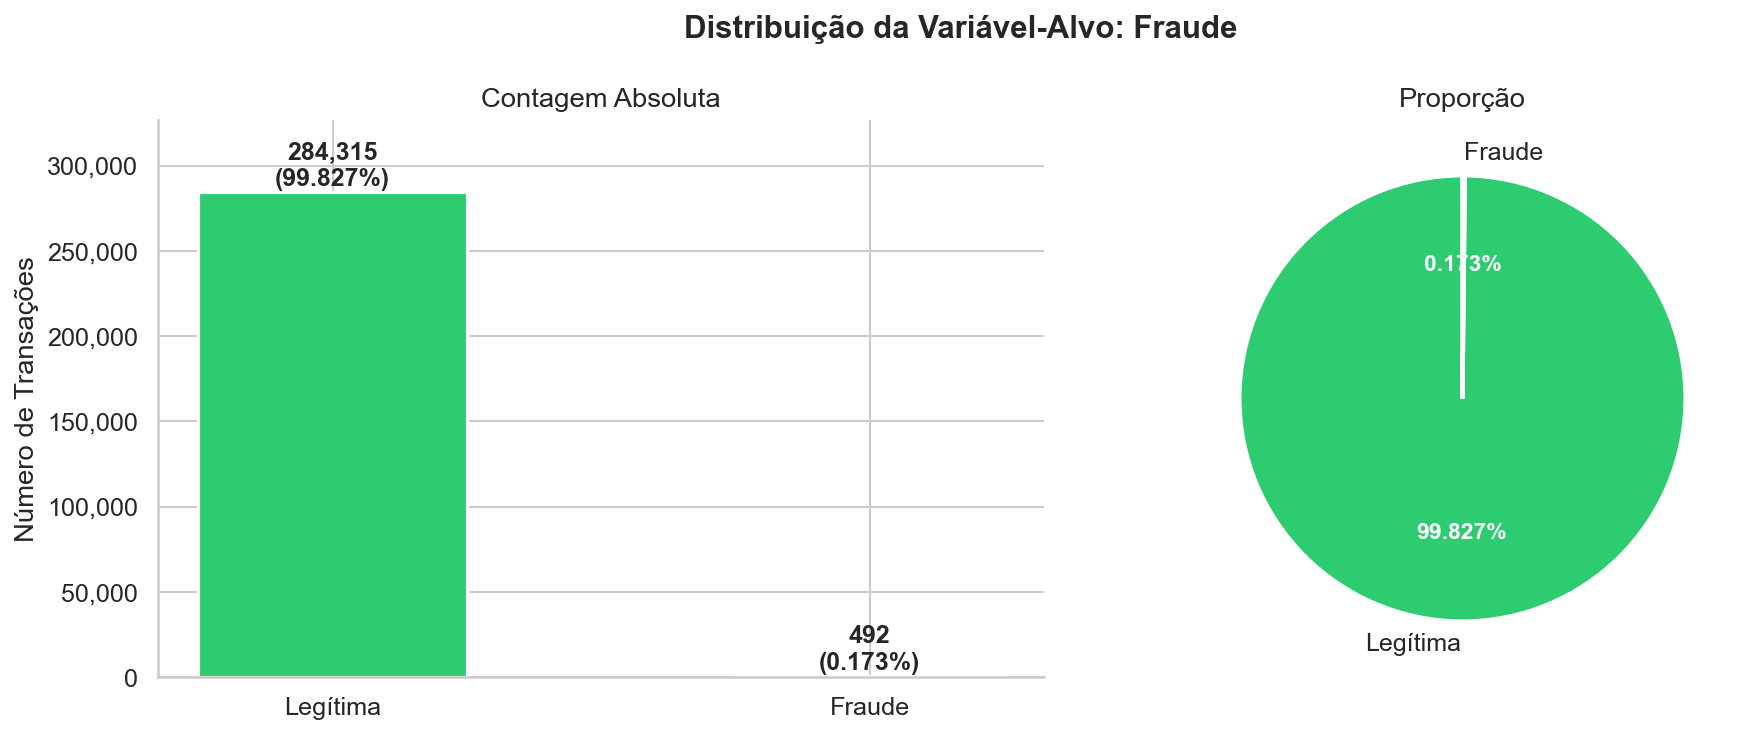

In [5]:
contagem   = df['Class'].value_counts()
proporcoes = df['Class'].value_counts(normalize=True) * 100

print('Distribuição da Variável-Alvo')
print(f'Legítimas (0): {contagem[0]:,}  ({proporcoes[0]:.3f}%)')
print(f'Fraudes   (1): {contagem[1]:,}  ({proporcoes[1]:.3f}%)')
print(f'\nRatio de desbalanceamento: 1:{contagem[0]//contagem[1]}')

# Confirmação com dados do Kaggle
print(f'\nConfere com Kaggle: 284.807 transações, 492 fraudes (0,172%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuição da Variável-Alvo: Fraude', fontsize=15, fontweight='bold')

# Barras
ax = axes[0]
bars = ax.bar(['Legítima', 'Fraude'], contagem.values,
              color=[COR_LEGIT, COR_FRAUDE], width=0.5,
              edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, contagem.values, proporcoes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}\n({pct:.3f}%)', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Transações')
ax.set_title('Contagem Absoluta')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, contagem[0] * 1.15)

# Pizza
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    contagem.values, labels=['Legítima', 'Fraude'],
    colors=[COR_LEGIT, COR_FRAUDE], autopct='%1.3f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set(fontsize=11, fontweight='bold', color='white')
ax.set_title('Proporção')

plt.tight_layout()
save_fig('01_distribuicao_target')

---
## **Análise da Variável `Time`:**

`Time` representa segundos desde a primeira transação — cobrindo ~48 horas.

Período total: 48.0 horas (~2.0 dias)
Mínimo: 0s  |  Máximo: 172792s
Salvo: ..\figures\02_analise_time.png


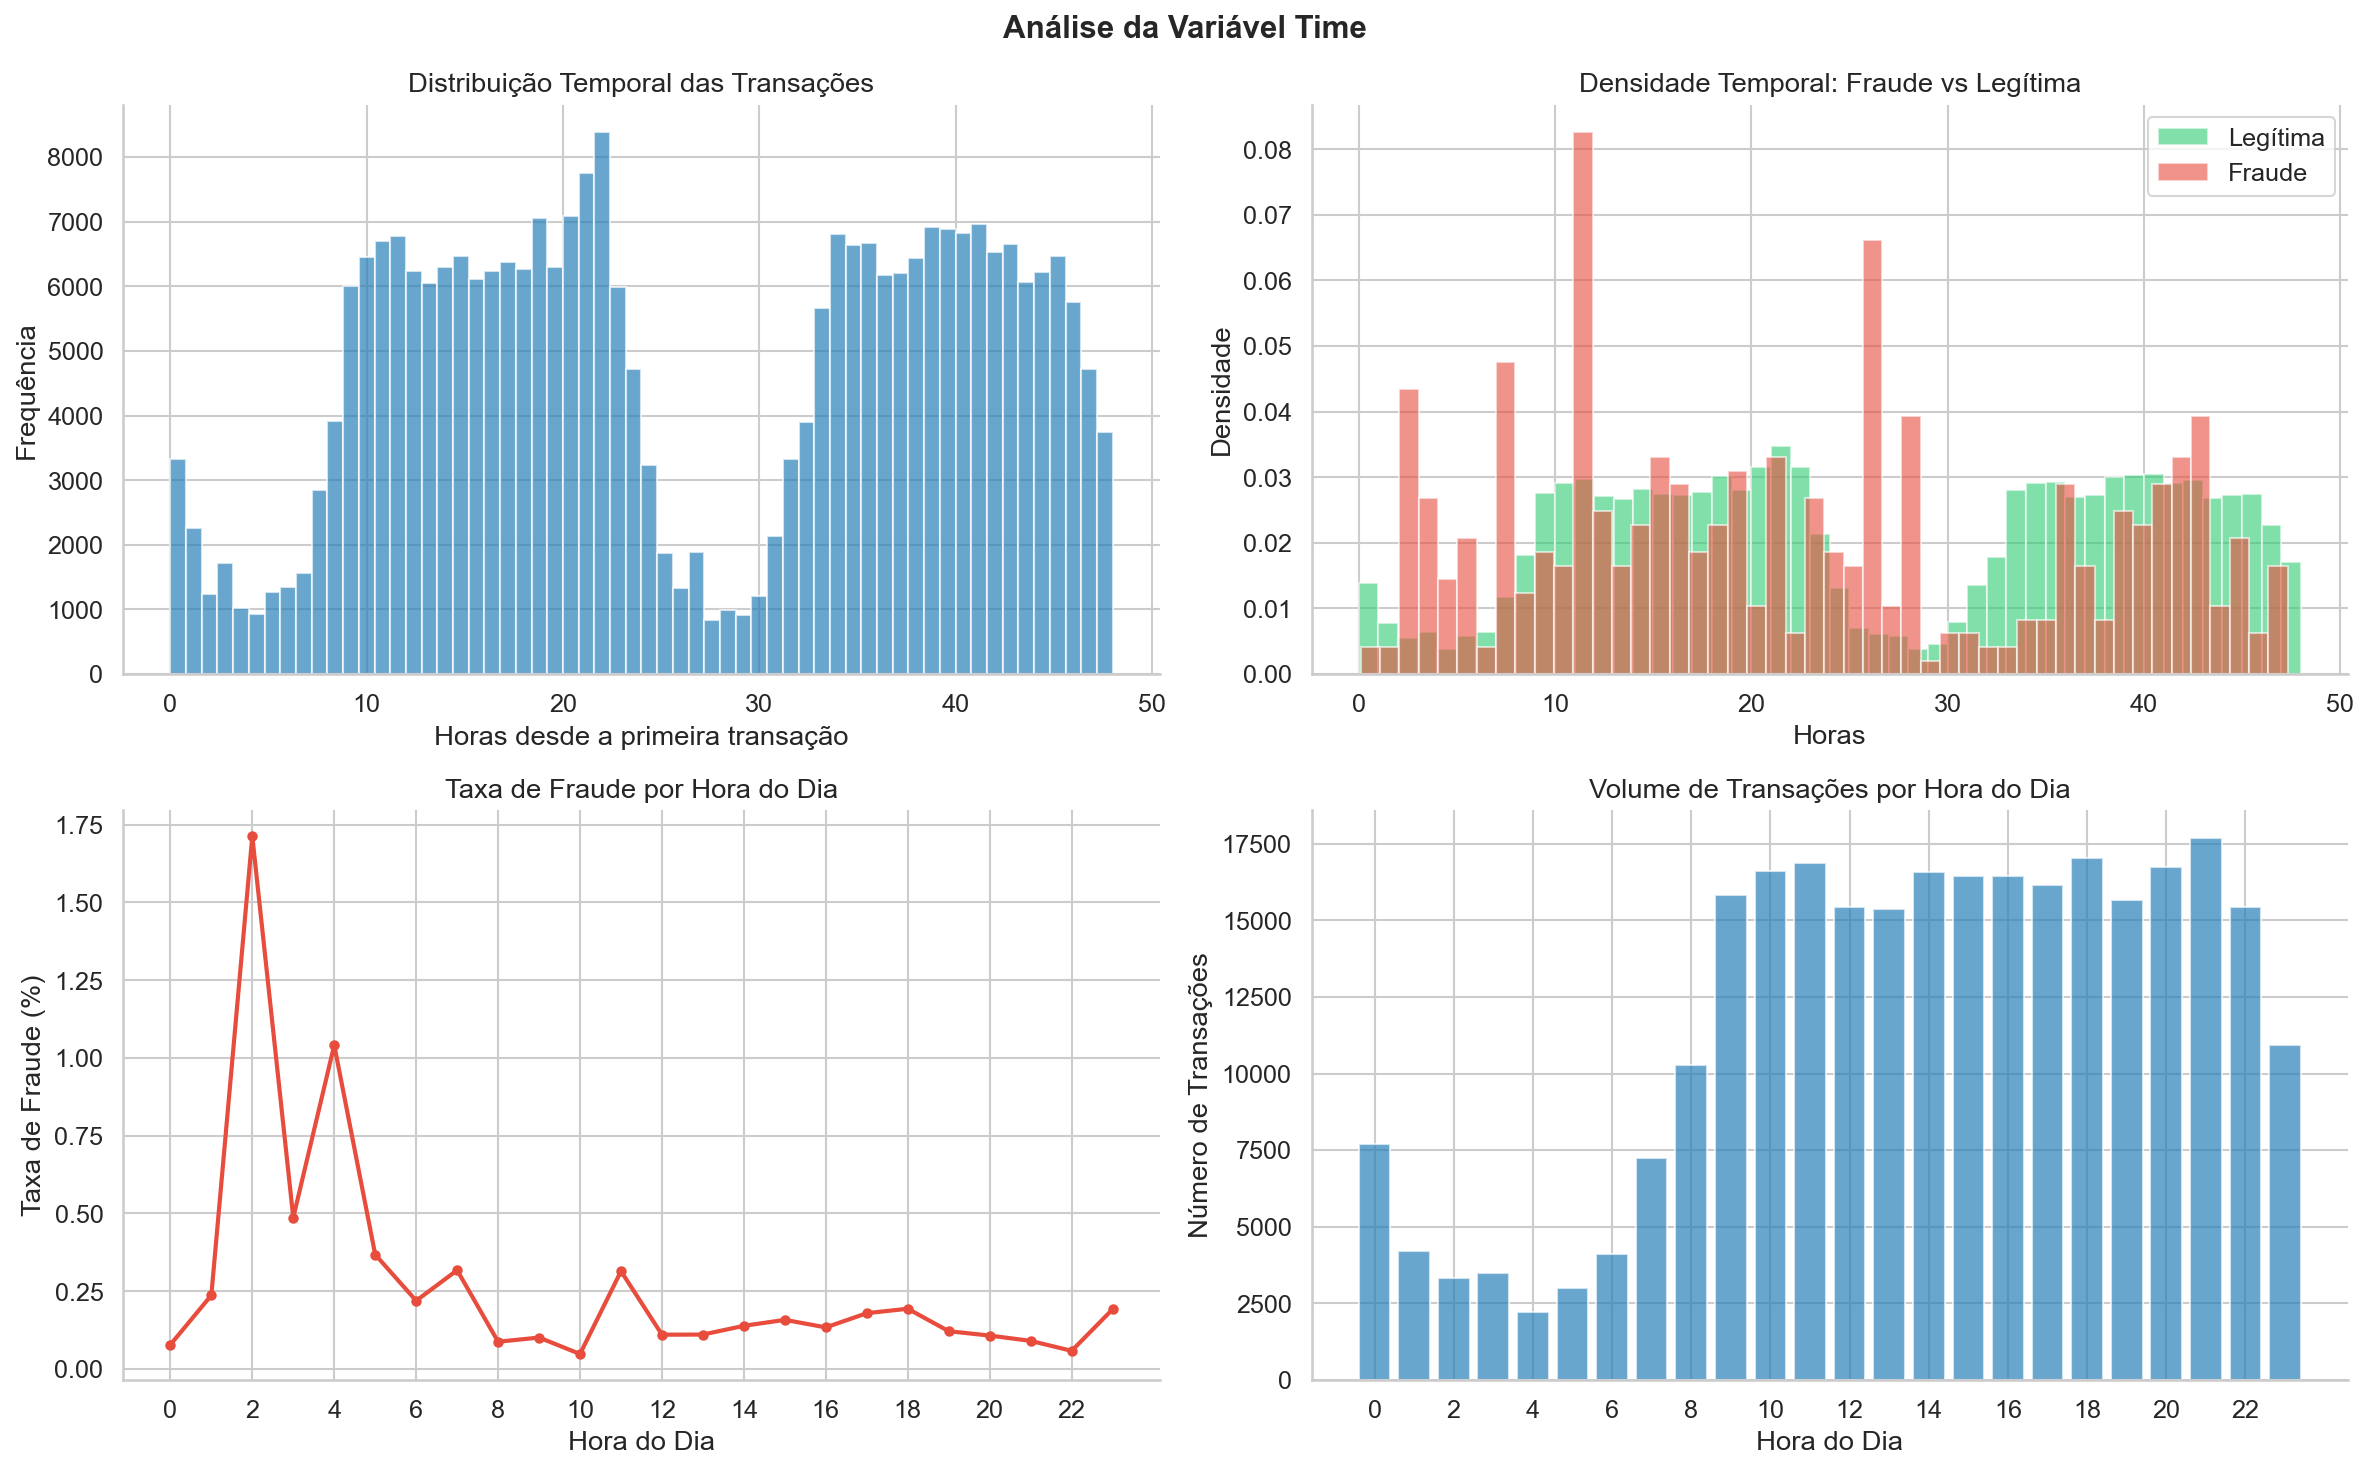

In [6]:
df['Time_Hours'] = df['Time'] / 3600

print(f'Período total: {df["Time_Hours"].max():.1f} horas (~{df["Time_Hours"].max()/24:.1f} dias)')
print(f'Mínimo: {df["Time"].min():.0f}s  |  Máximo: {df["Time"].max():.0f}s')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análise da Variável Time', fontsize=15, fontweight='bold')

# Distribuição geral
ax = axes[0, 0]
ax.hist(df['Time_Hours'], bins=60, color=COR_ACCENT, alpha=0.7, edgecolor='white')
ax.set_xlabel('Horas desde a primeira transação')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição Temporal das Transações')

# Fraudes x legítimas ao longo do tempo
ax = axes[0, 1]
for label, cor in [(0, COR_LEGIT), (1, COR_FRAUDE)]:
    nome = 'Legítima' if label == 0 else 'Fraude'
    ax.hist(df[df['Class'] == label]['Time_Hours'],
            bins=48, alpha=0.6, color=cor, label=nome, density=True)
ax.set_xlabel('Horas')
ax.set_ylabel('Densidade')
ax.set_title('Densidade Temporal: Fraude vs Legítima')
ax.legend()

# Taxa de fraude por hora
ax = axes[1, 0]
df['Time_Hour_Bin'] = (df['Time_Hours'] % 24).astype(int)
taxa_hora = df.groupby('Time_Hour_Bin')['Class'].mean() * 100
ax.plot(taxa_hora.index, taxa_hora.values, color=COR_FRAUDE,
        linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Taxa de Fraude (%)')
ax.set_title('Taxa de Fraude por Hora do Dia')
ax.set_xticks(range(0, 24, 2))

# Volume por hora
ax = axes[1, 1]
volume_hora = df.groupby('Time_Hour_Bin').size()
ax.bar(volume_hora.index, volume_hora.values, color=COR_ACCENT, alpha=0.7)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Número de Transações')
ax.set_title('Volume de Transações por Hora do Dia')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
save_fig('02_analise_time')

## **Análise da Variável `Amount`:**

Estatísticas de Amount por Classe

Legítimas:
  Média:    $88.29
  Mediana:  $22.00
  Máximo:   $25691.16
  Desvio:   $250.11

Fraudes:
  Média:    $122.21
  Mediana:  $9.25
  Máximo:   $2125.87
  Desvio:   $256.68

Teste Mann-Whitney — p-valor: 8.58e-06
→ Diferença significativa entre as distribuições (α=0.05)
Salvo: ..\figures\03_analise_amount.png


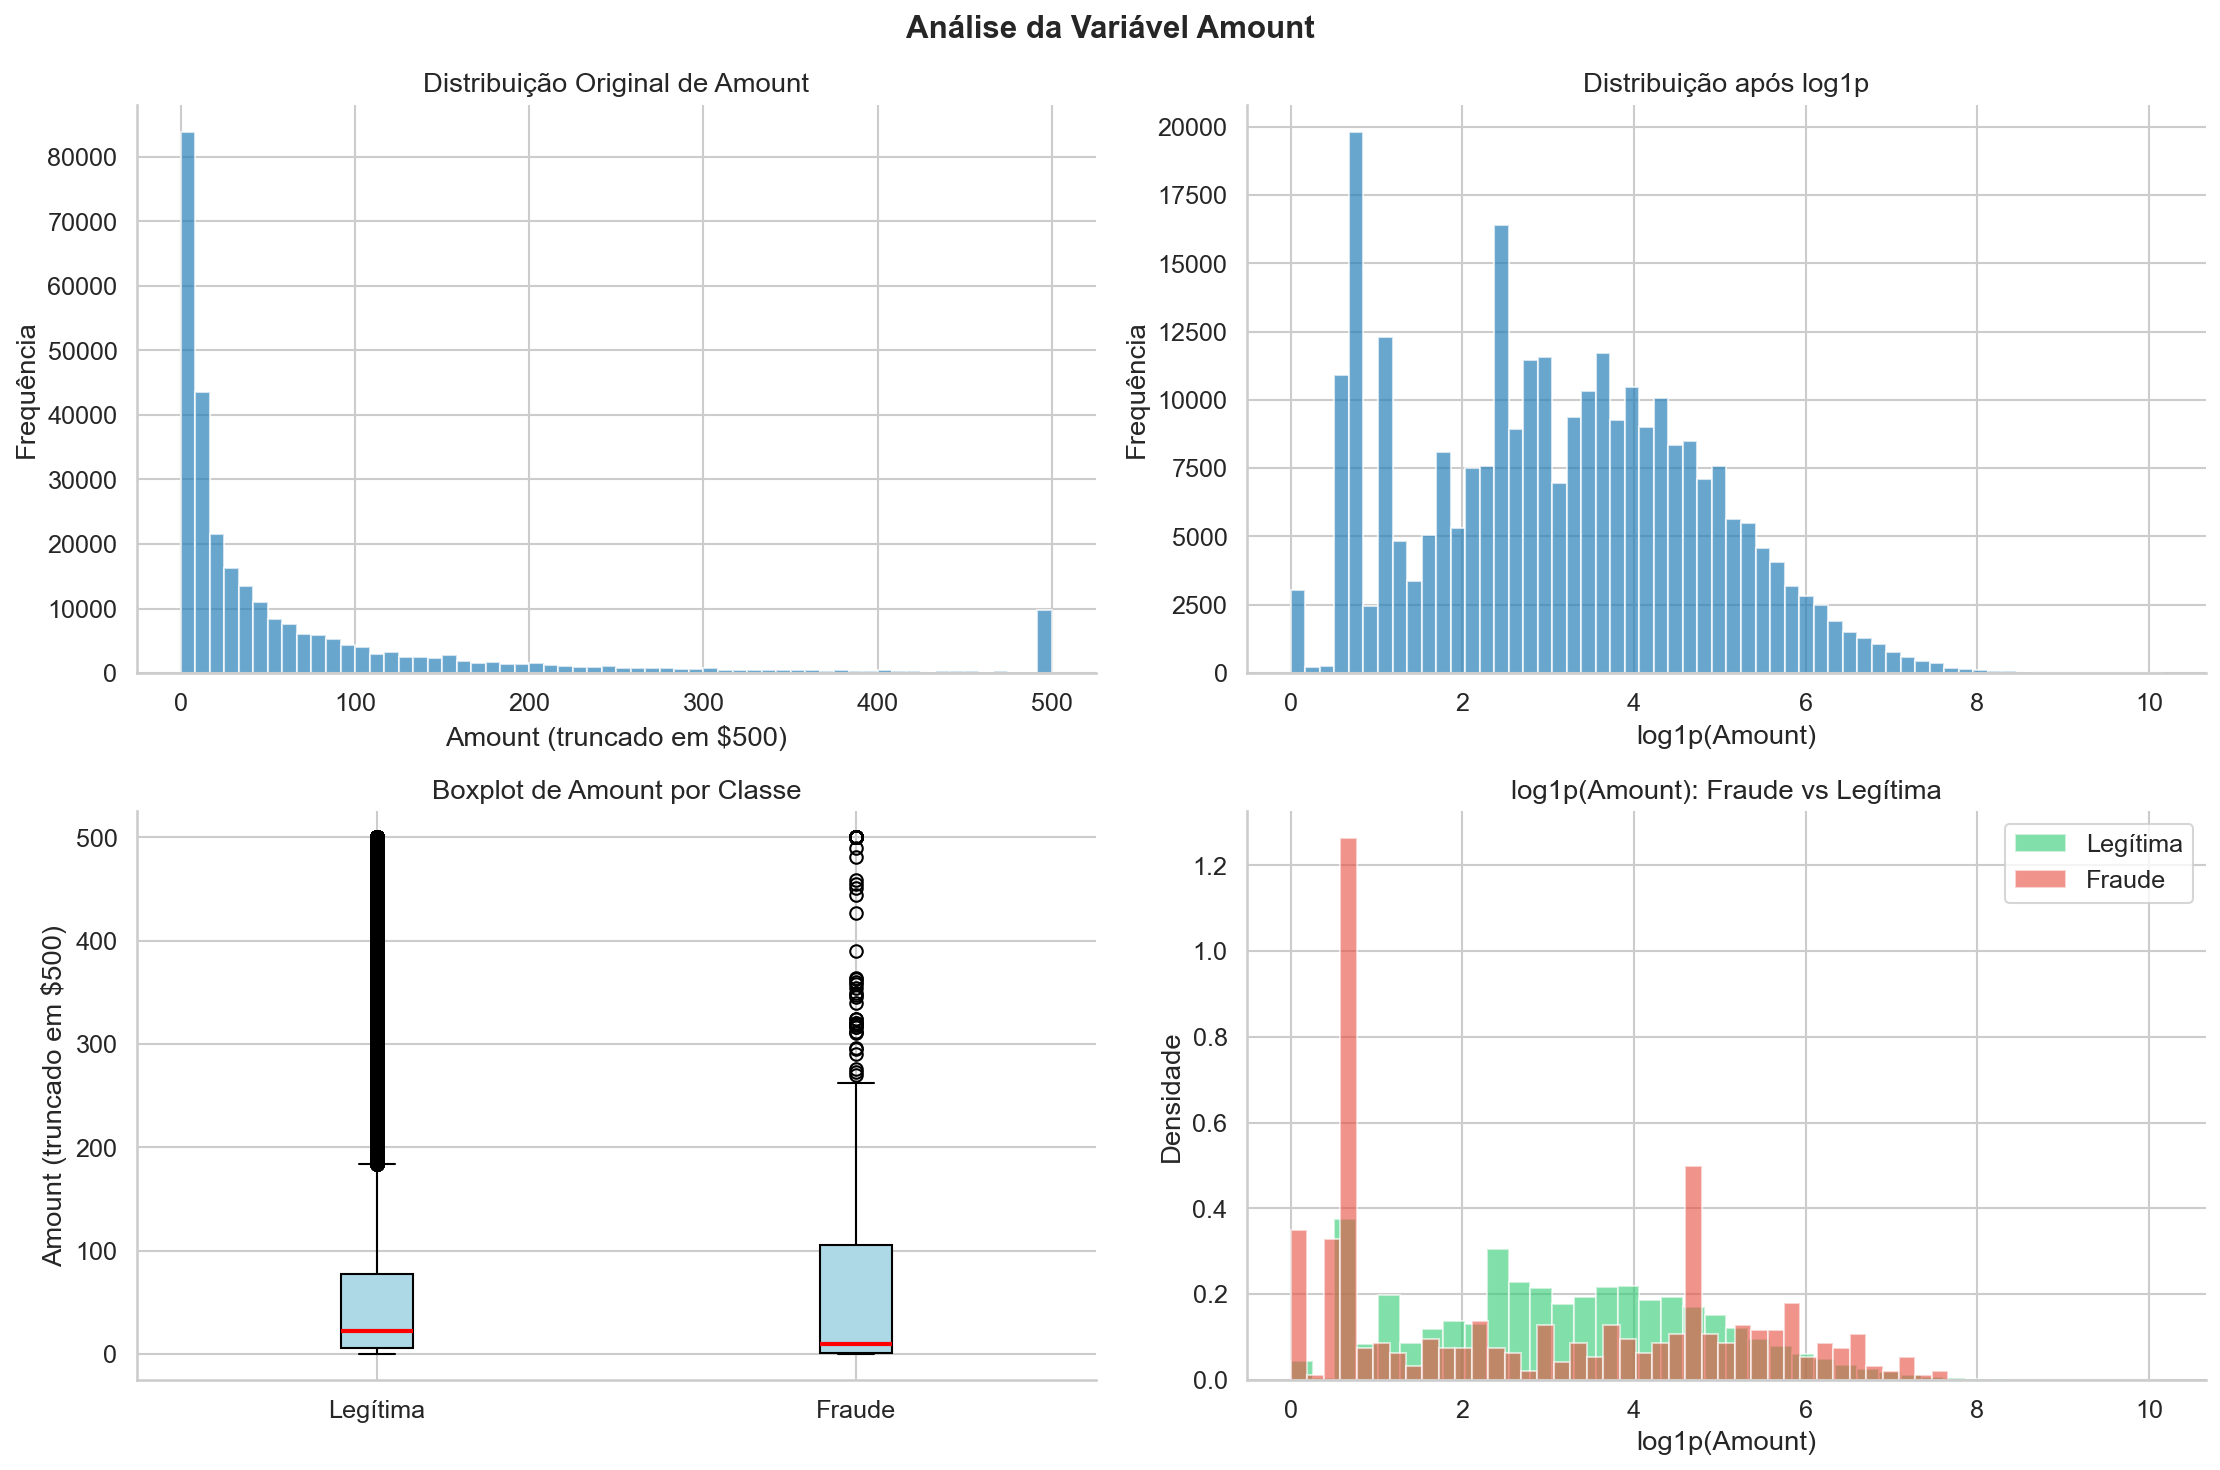

In [7]:
print('Estatísticas de Amount por Classe')
for classe in [0, 1]:
    nome = 'Legítimas' if classe == 0 else 'Fraudes'
    dados = df[df['Class'] == classe]['Amount']
    print(f'\n{nome}:')
    print(f'  Média:    ${dados.mean():.2f}')
    print(f'  Mediana:  ${dados.median():.2f}')
    print(f'  Máximo:   ${dados.max():.2f}')
    print(f'  Desvio:   ${dados.std():.2f}')

# Teste estatístico
stat, p_value = stats.mannwhitneyu(
    df[df['Class'] == 0]['Amount'],
    df[df['Class'] == 1]['Amount'],
    alternative='two-sided'
)
print(f'\nTeste Mann-Whitney — p-valor: {p_value:.2e}')
print(f'→ Diferença {"significativa" if p_value < 0.05 else "não significativa"} entre as distribuições (α=0.05)')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise da Variável Amount', fontsize=15, fontweight='bold')

# Distribuição original
ax = axes[0, 0]
ax.hist(df['Amount'].clip(upper=500), bins=60,
        color=COR_ACCENT, alpha=0.7, edgecolor='white')
ax.set_xlabel('Amount (truncado em $500)')
ax.set_title('Distribuição Original de Amount')
ax.set_ylabel('Frequência')

# Log transform
ax = axes[0, 1]
ax.hist(np.log1p(df['Amount']), bins=60,
        color=COR_ACCENT, alpha=0.7, edgecolor='white')
ax.set_xlabel('log1p(Amount)')
ax.set_title('Distribuição após log1p')
ax.set_ylabel('Frequência')

# Boxplot por classe
ax = axes[1, 0]
data_legit  = df[df['Class'] == 0]['Amount'].clip(upper=500)
data_fraude = df[df['Class'] == 1]['Amount'].clip(upper=500)
ax.boxplot([data_legit, data_fraude],
           labels=['Legítima', 'Fraude'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Amount (truncado em $500)')
ax.set_title('Boxplot de Amount por Classe')

# Histograma comparativo (log)
ax = axes[1, 1]
for label, cor in [(0, COR_LEGIT), (1, COR_FRAUDE)]:
    nome = 'Legítima' if label == 0 else 'Fraude'
    ax.hist(np.log1p(df[df['Class'] == label]['Amount']),
            bins=40, alpha=0.6, color=cor, label=nome, density=True)
ax.set_xlabel('log1p(Amount)')
ax.set_ylabel('Densidade')
ax.set_title('log1p(Amount): Fraude vs Legítima')
ax.legend()

plt.tight_layout()
save_fig('03_analise_amount')

## **Poder de Separação dos Componentes PCA:**

Como V1–V28 já são componentes PCA anonimizados, avaliamos quais têm maior poder discriminativo para fraude usando AUC-ROC univariado e teste de Mann-Whitney.

In [8]:
pca_cols = [col for col in df.columns if col.startswith('V')]
print(f'Componentes PCA: {len(pca_cols)} ({pca_cols[0]} ... {pca_cols[-1]})')

# Verificar padronização
medias = df[pca_cols].mean()
stds   = df[pca_cols].std()
print(f'\nVerificação de padronização:')
print(f'  Média das médias:      {medias.mean():.6f} (esperado: ~0)')
print(f'  Média dos desvios:     {stds.mean():.4f} (esperado: ~1)')

# AUC-ROC univariado + Mann-Whitney para cada componente
sep_metrics = []
for col in pca_cols:
    stat, p_val = stats.mannwhitneyu(
        df[df['Class'] == 0][col],
        df[df['Class'] == 1][col],
        alternative='two-sided'
    )
    auc = roc_auc_score(df['Class'], df[col])
    auc = max(auc, 1 - auc)  # garante AUC >= 0.5

    mean_legit = df[df['Class'] == 0][col].mean()
    mean_fraud = df[df['Class'] == 1][col].mean()
    cohens_d   = (mean_fraud - mean_legit) / df[col].std()

    sep_metrics.append({
        'Componente': col,
        'AUC-ROC'   : round(auc, 4),
        'p-valor'   : p_val,
        'Cohen\'s d': round(cohens_d, 4),
        'Média Legít': round(mean_legit, 4),
        'Média Fraude': round(mean_fraud, 4),
    })

df_sep = pd.DataFrame(sep_metrics).sort_values('AUC-ROC', ascending=False)
print('\nTop 10 Componentes por Poder de Separação')
print(df_sep.head(10).to_string(index=False))

Componentes PCA: 28 (V1 ... V28)

Verificação de padronização:
  Média das médias:      0.000000 (esperado: ~0)
  Média dos desvios:     0.9764 (esperado: ~1)

Top 10 Componentes por Poder de Separação
Componente  AUC-ROC       p-valor  Cohen's d  Média Legít  Média Fraude
       V14   0.9492 1.471581e-260    -7.2854       0.0121       -6.9717
        V4   0.9383 3.625904e-248     3.2135      -0.0079        4.5420
       V12   0.9370 8.416027e-247    -6.2752       0.0108       -6.2594
       V11   0.9181 4.910592e-226     3.7295      -0.0066        3.8002
       V10   0.9141 9.611131e-222    -5.2227       0.0098       -5.6769
        V3   0.9121 1.211048e-219    -4.6466       0.0122       -7.0333
        V2   0.8550 1.650438e-163     2.1983      -0.0063        3.6238
       V16   0.8471 1.808172e-156    -4.7328       0.0072       -4.1399
        V9   0.8441 8.943723e-154    -2.3535       0.0045       -2.5811
        V7   0.8358 1.464234e-146    -4.5093       0.0096       -5.5687


Salvo: ..\figures\04_poder_separacao_pca.png


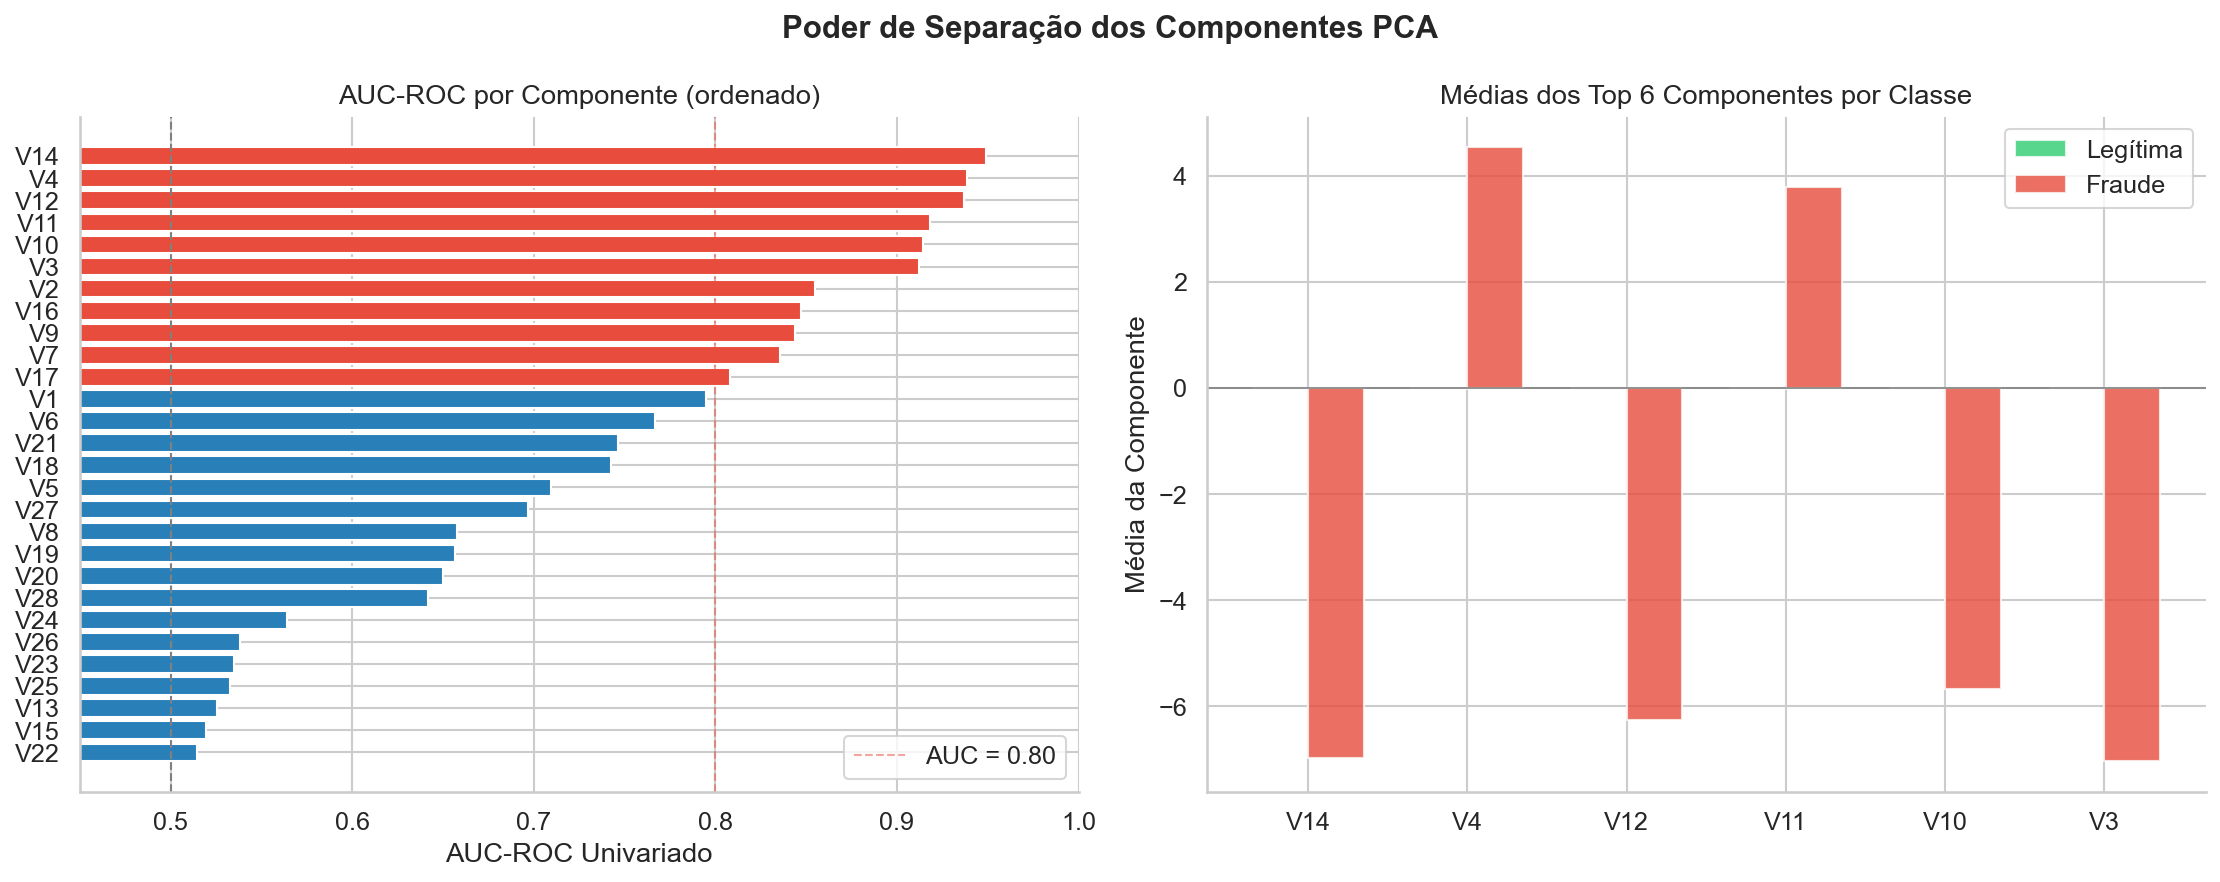

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Poder de Separação dos Componentes PCA', fontsize=15, fontweight='bold')

# AUC por componente
ax = axes[0]
cores_bar = [COR_FRAUDE if auc >= 0.80 else COR_ACCENT
             for auc in df_sep['AUC-ROC']]
bars = ax.barh(df_sep['Componente'], df_sep['AUC-ROC'],
               color=cores_bar, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.axvline(0.8, color=COR_FRAUDE, linestyle='--', linewidth=1,
           alpha=0.5, label='AUC = 0.80')
ax.set_xlabel('AUC-ROC Univariado')
ax.set_title('AUC-ROC por Componente (ordenado)')
ax.invert_yaxis()
ax.set_xlim(0.45, 1.0)
ax.legend()

# Distribuição dos top 6 componentes
ax = axes[1]
top6 = df_sep.head(6)['Componente'].tolist()
mean_fraud = df[df['Class'] == 1][top6].mean()
mean_legit = df[df['Class'] == 0][top6].mean()
x = np.arange(len(top6))
w = 0.35
ax.bar(x - w/2, mean_legit.values, w, label='Legítima',
       color=COR_LEGIT, alpha=0.8)
ax.bar(x + w/2, mean_fraud.values, w, label='Fraude',
       color=COR_FRAUDE, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top6)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Média da Componente')
ax.set_title('Médias dos Top 6 Componentes por Classe')
ax.legend()

plt.tight_layout()
save_fig('04_poder_separacao_pca')

## **Distribuições dos Top Componentes PCA:**

Salvo: ..\figures\05_distribuicoes_top_pca.png


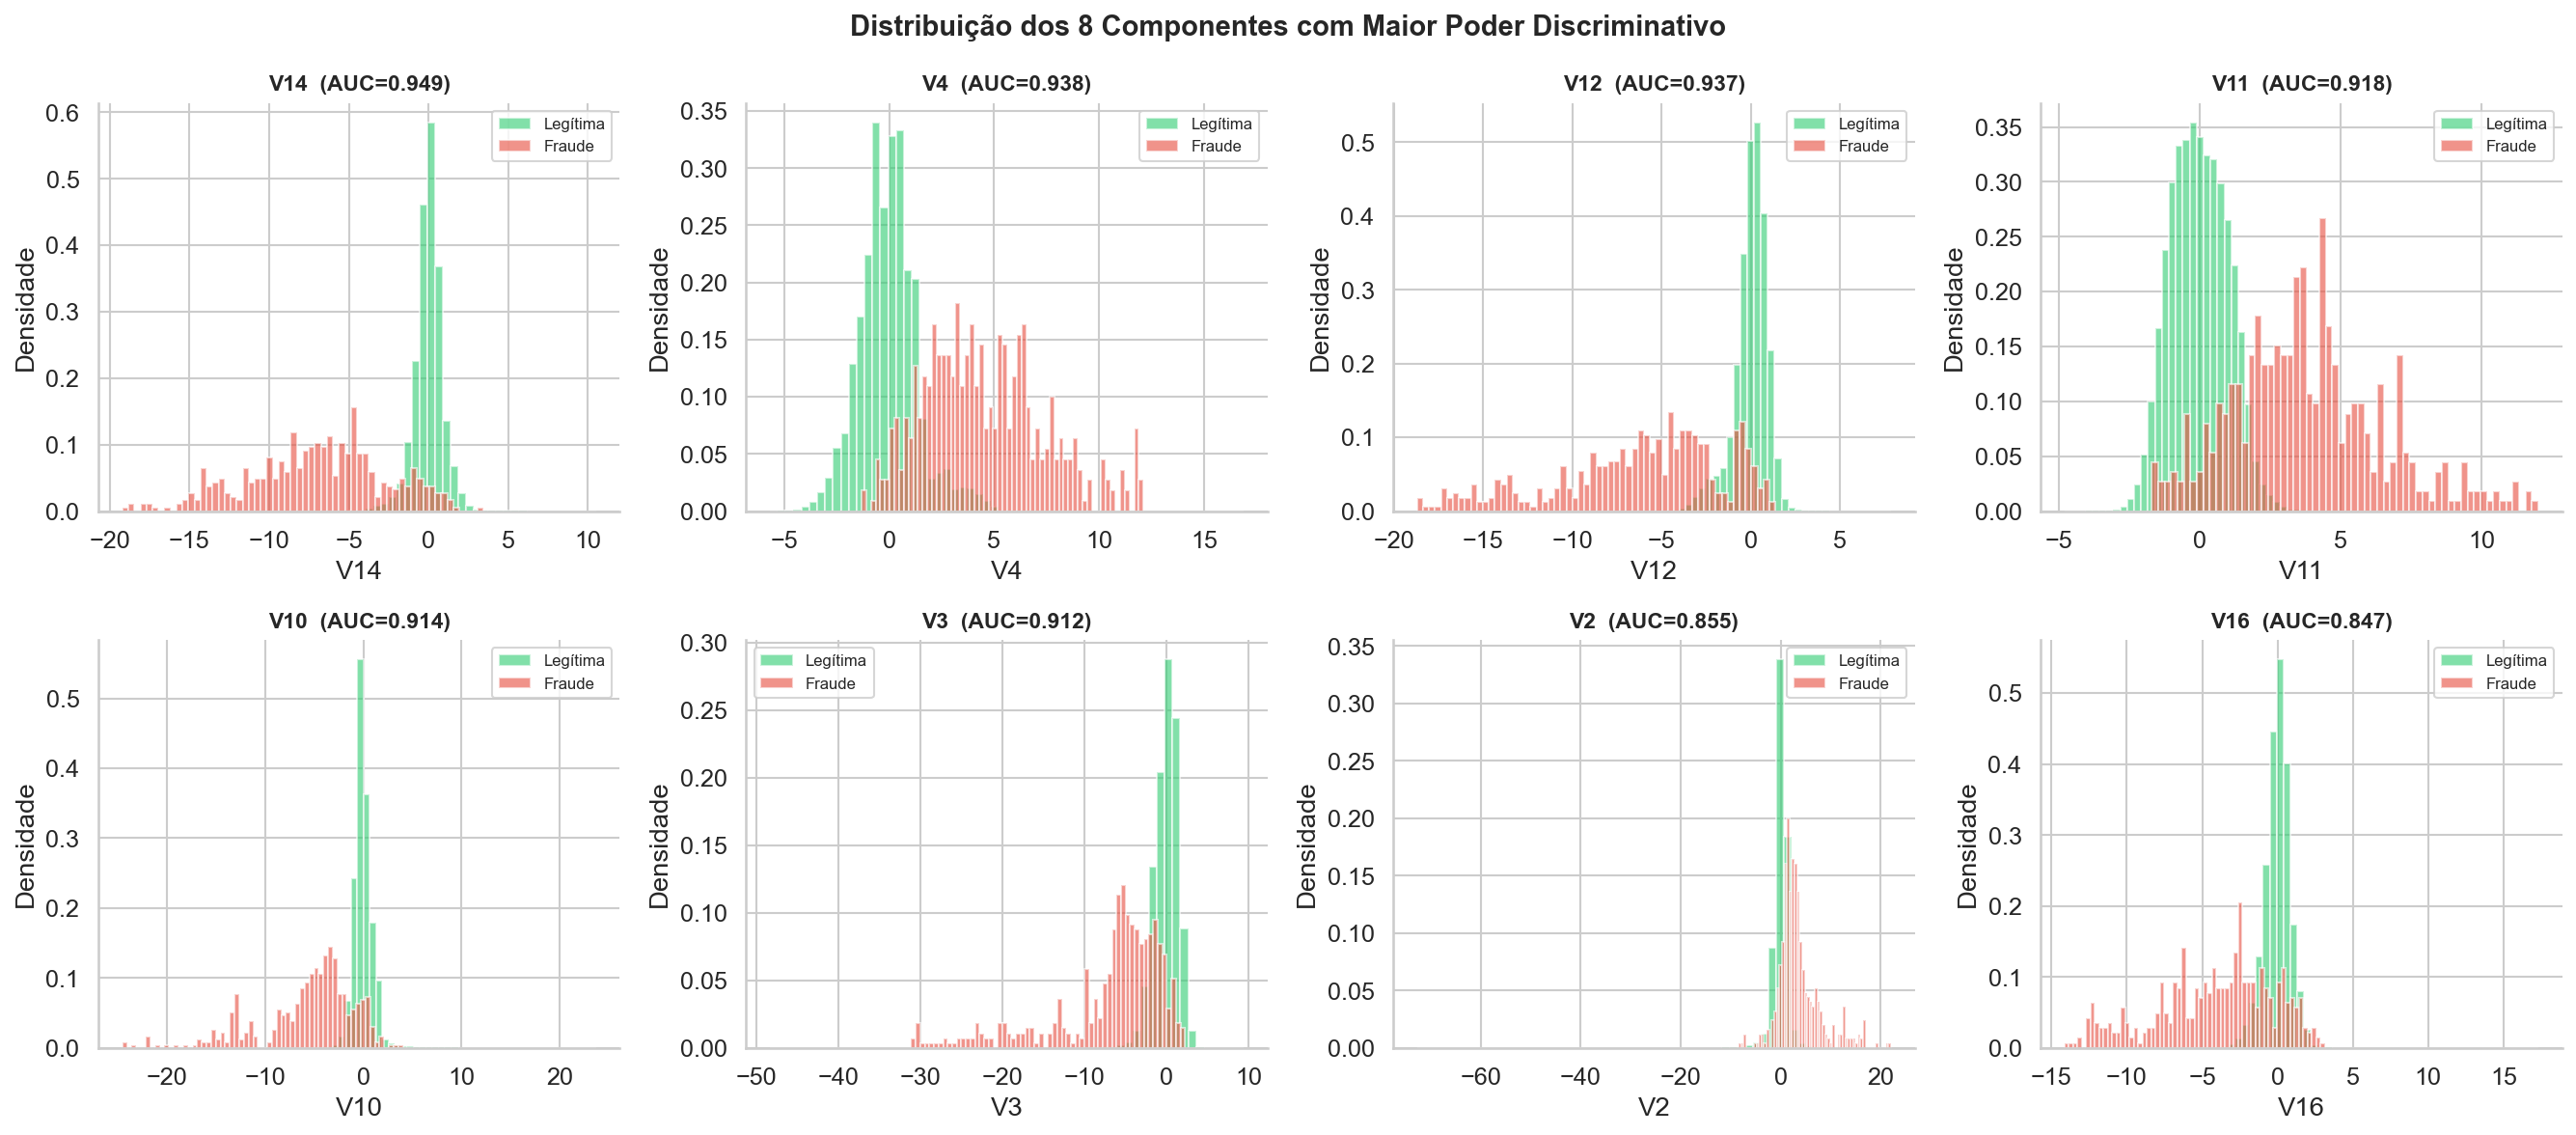

In [10]:
top8 = df_sep.head(8)['Componente'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribuição dos 8 Componentes com Maior Poder Discriminativo',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.ravel(), top8):
    auc = df_sep[df_sep['Componente'] == col]['AUC-ROC'].values[0]
    for label, cor in [(0, COR_LEGIT), (1, COR_FRAUDE)]:
        nome = 'Legítima' if label == 0 else 'Fraude'
        ax.hist(df[df['Class'] == label][col],
                bins=60, alpha=0.6, color=cor,
                label=nome, density=True)
    ax.set_title(f'{col}  (AUC={auc:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)

plt.tight_layout()
save_fig('05_distribuicoes_top_pca')

## **Análise de Outliers:**

=== Top 10 Componentes com Mais Outliers ===
Componente  Outliers  Pct (%)
       V27     39163    13.75
       V28     30342    10.65
       V20     27770     9.75
        V8     24134     8.47
        V6     22965     8.06
       V23     18541     6.51
       V12     15348     5.39
       V21     14497     5.09
       V14     14149     4.97
        V2     13526     4.75
Salvo: ..\figures\06_outliers_pca.png


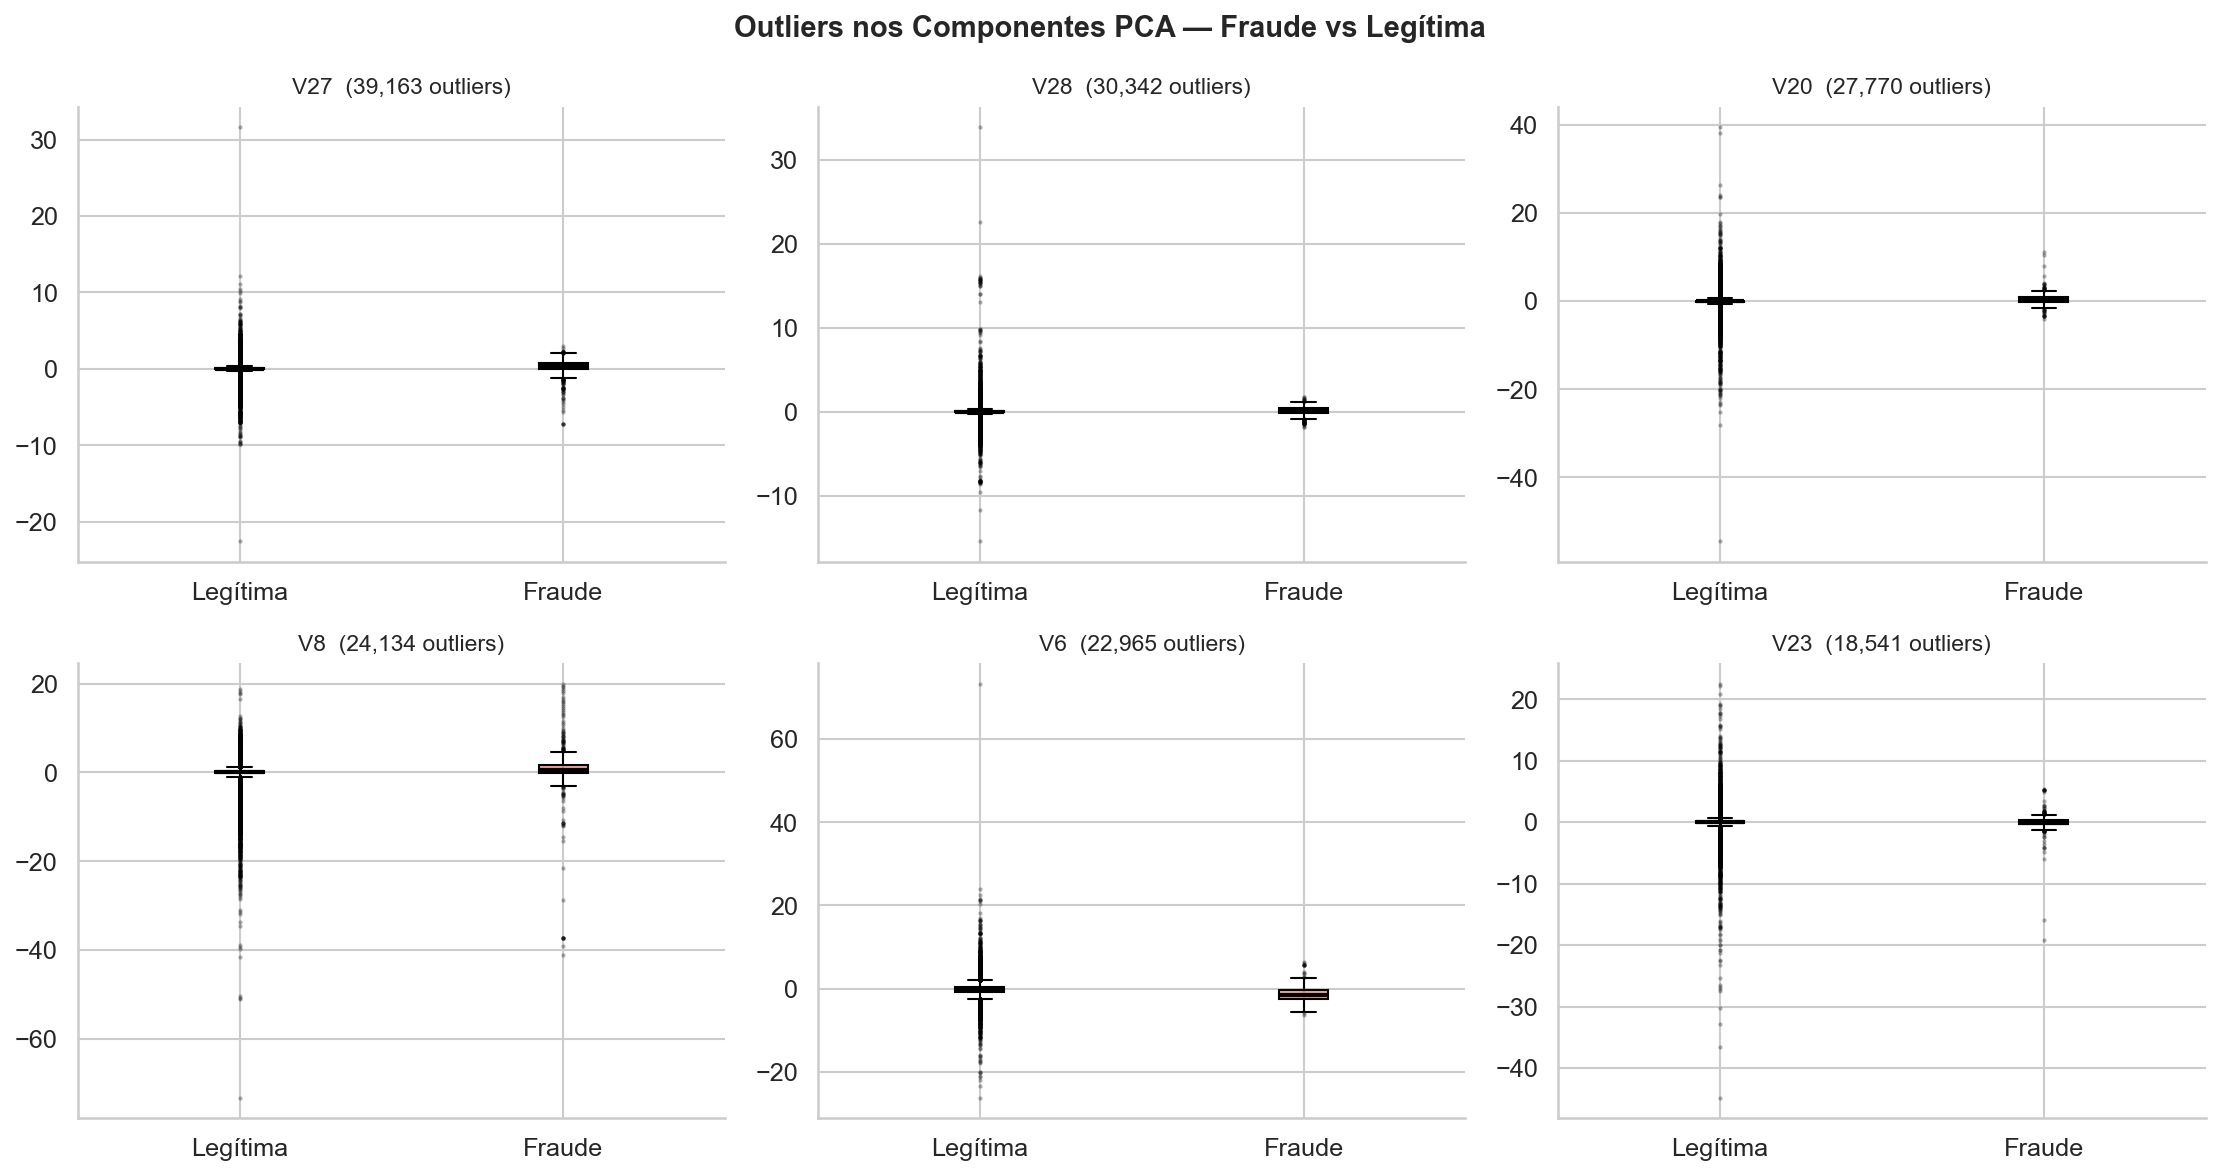

In [11]:
outliers_info = []
for col in pca_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outliers_info.append({
        'Componente': col,
        'Outliers'  : n_out,
        'Pct (%)'   : round(n_out / len(df) * 100, 2),
    })

df_out = pd.DataFrame(outliers_info).sort_values('Outliers', ascending=False)
print('=== Top 10 Componentes com Mais Outliers ===')
print(df_out.head(10).to_string(index=False))

# Boxplot dos top 6 com mais outliers
top6_out = df_out.head(6)['Componente'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Outliers nos Componentes PCA — Fraude vs Legítima',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.ravel(), top6_out):
    data = [df[df['Class'] == 0][col].values,
            df[df['Class'] == 1][col].values]
    bp = ax.boxplot(data, labels=['Legítima', 'Fraude'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    bp['boxes'][0].set_facecolor(COR_LEGIT + '80')
    bp['boxes'][1].set_facecolor(COR_FRAUDE + '80')
    n_out = df_out[df_out['Componente'] == col]['Outliers'].values[0]
    ax.set_title(f'{col}  ({n_out:,} outliers)', fontsize=11)

plt.tight_layout()
save_fig('06_outliers_pca')

## **Matriz de Correlação:**

Correlações entre Componentes PCA
Média:           -0.000000
Desvio padrão:   0.000000
Máxima:          0.000000
Mínima:          -0.000000
Pares com |r|>0.1: 0
- PCA cumpriu seu papel: componentes praticamente não correlacionados.
Salvo: ..\figures\07_correlacao_pca.png


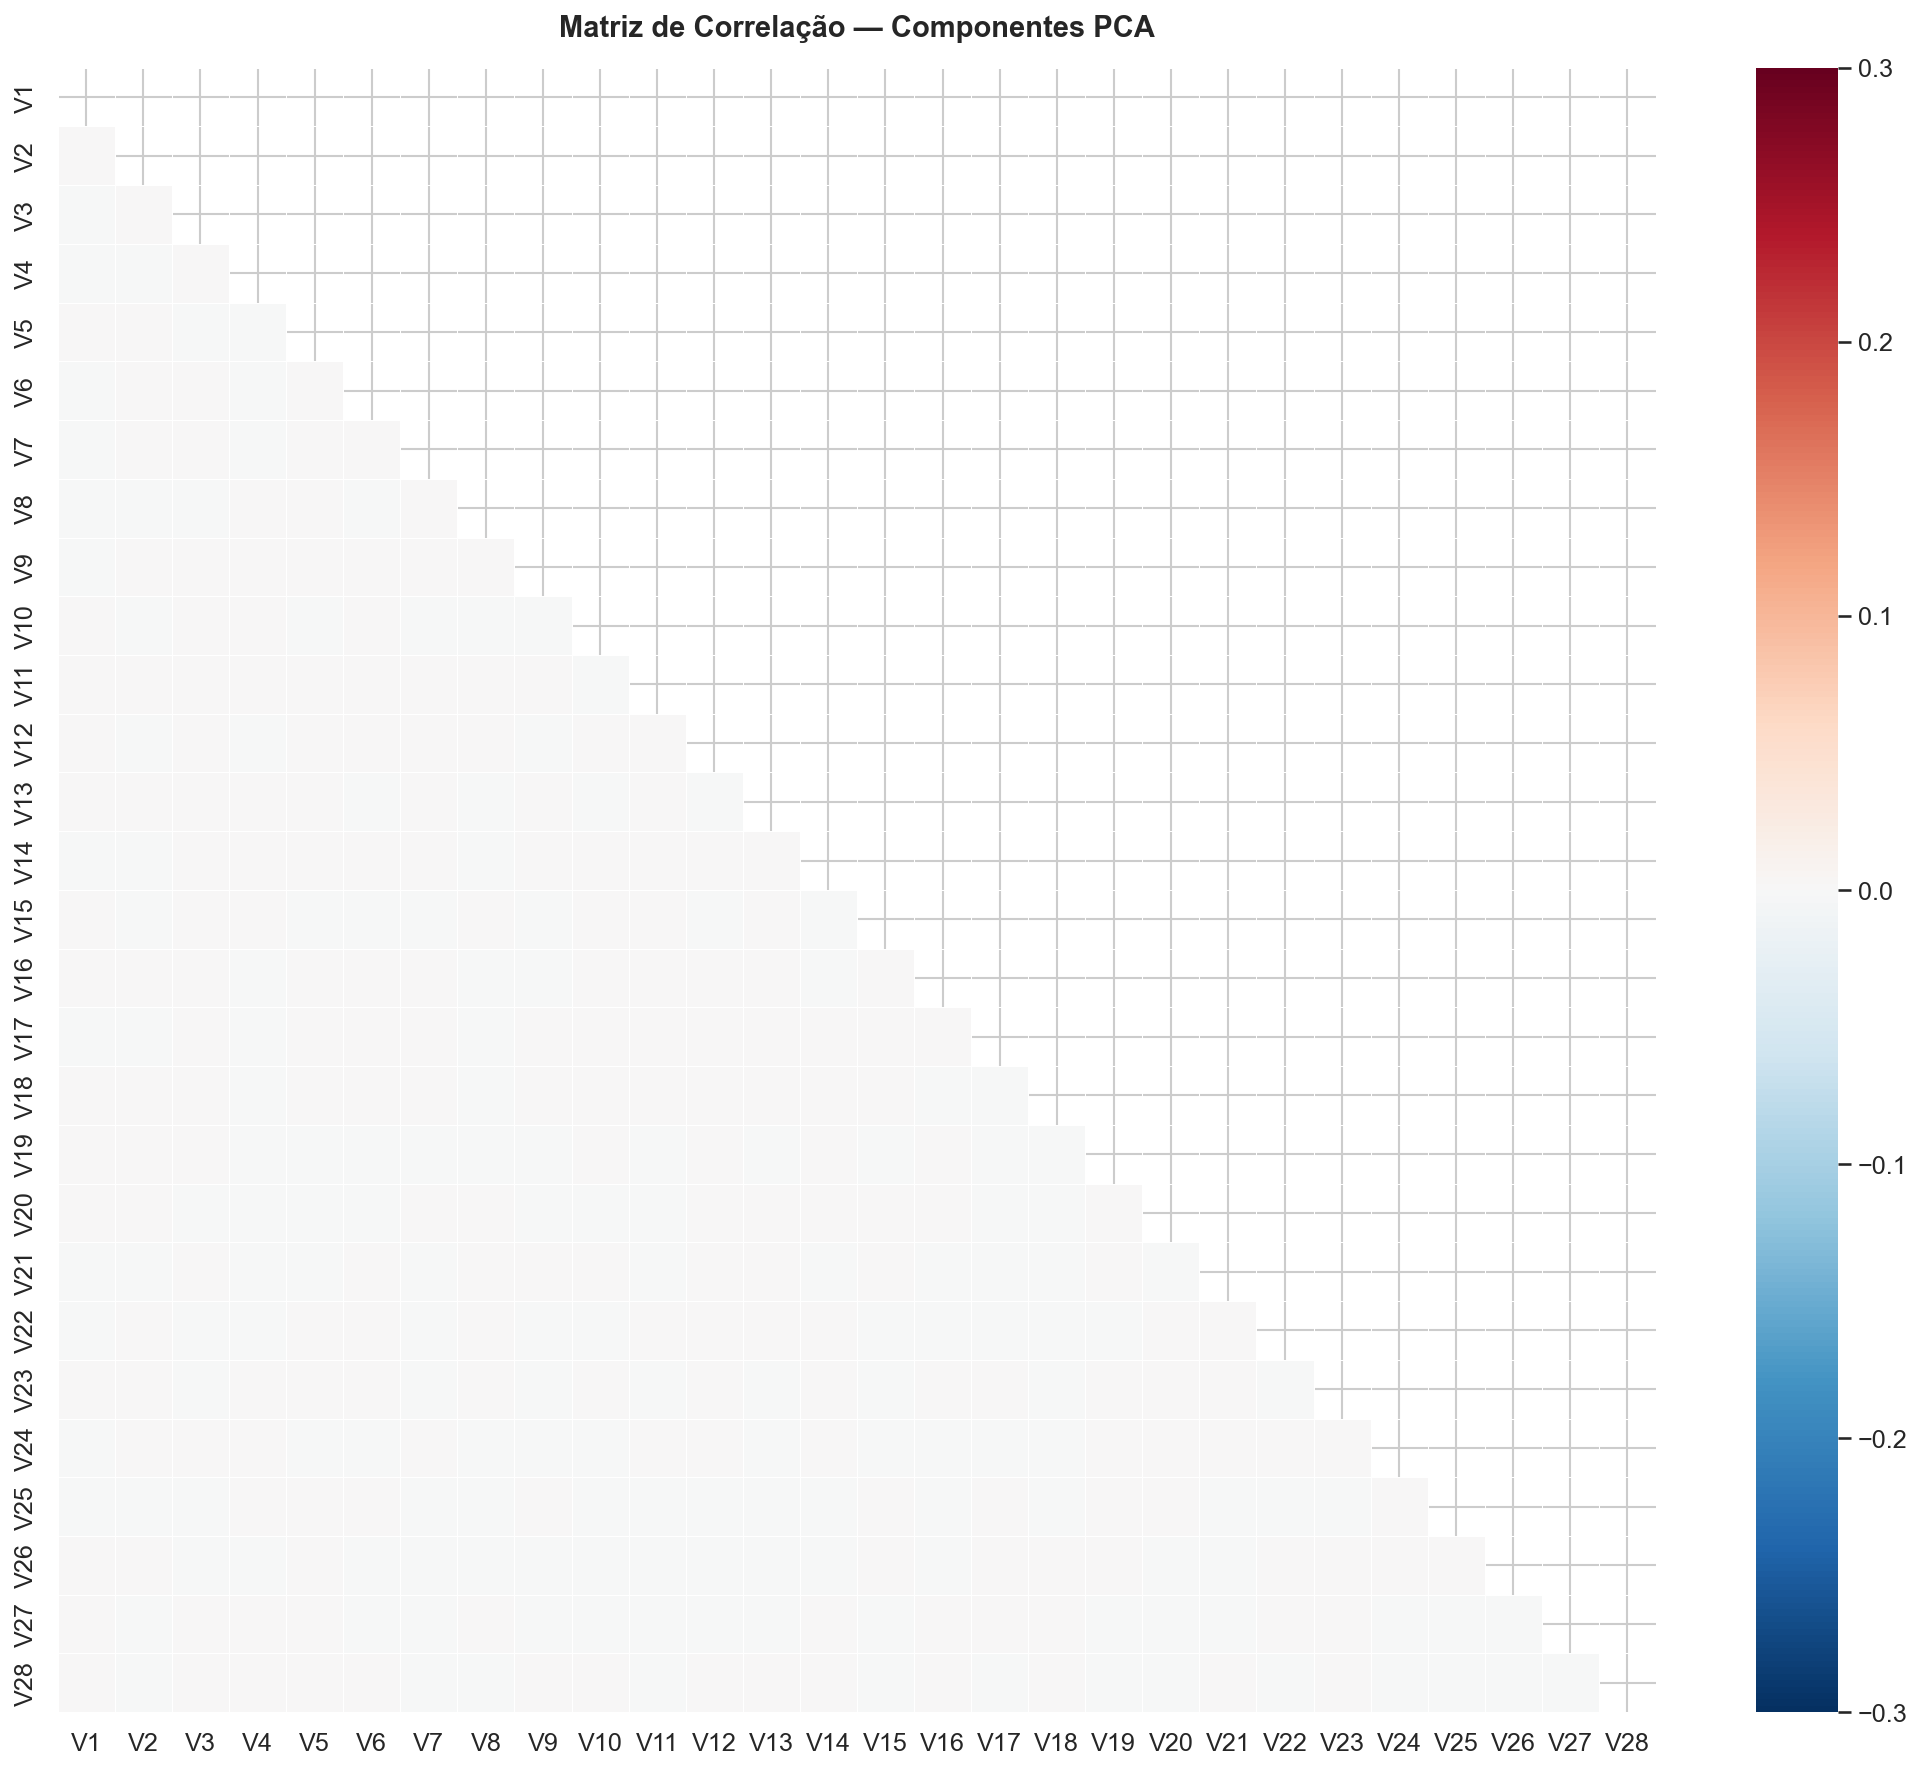

In [13]:
corr = df[pca_cols].corr()
corr_vals = corr.values[np.triu_indices_from(corr.values, k=1)]

print('Correlações entre Componentes PCA')
print(f'Média:           {np.mean(corr_vals):.6f}')
print(f'Desvio padrão:   {np.std(corr_vals):.6f}')
print(f'Máxima:          {np.max(corr_vals):.6f}')
print(f'Mínima:          {np.min(corr_vals):.6f}')
print(f'Pares com |r|>0.1: {(np.abs(corr_vals) > 0.1).sum()}')
print('- PCA cumpriu seu papel: componentes praticamente não correlacionados.')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r',
            vmin=-0.3, vmax=0.3, linewidths=0.3,
            linecolor='white', ax=ax)
ax.set_title('Matriz de Correlação — Componentes PCA',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
save_fig('07_correlacao_pca')

## **Resumo e Decisões para Modelagem:**

In [14]:
top3 = df_sep.head(3)['Componente'].tolist()
taxa_fraude = df['Class'].mean() * 100
ratio = contagem[0] // contagem[1]

print(f"""
╔══════════════════════════════════════════════════════════════╗
║            RESUMO DA EDA — DECISÕES PARA MODELAGEM           ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║   Total de transações : {df.shape[0]:,}                      ║
║   Fraudes             : {contagem[1]:,} ({taxa_fraude:.3f}%)               ║
║   Ratio desbalanceam. : 1:{ratio}                           ║
╠══════════════════════════════════════════════════════════════╣
║  FEATURES                                                    ║
║   V1–V28 já padronizados (média~0, std~1)                    ║
║   Amount - aplicar log1p (assimetria forte)                  ║
║   Time   - criar features cíclicas sin/cos                   ║
║   Top componentes: {', '.join(top3):<36}║
╠══════════════════════════════════════════════════════════════╣
║  ESTRATÉGIA DE MODELAGEM                                     ║
║   Divisão: temporal (80/20 por Time) — evita data leakage   ║
║   Balanceamento: comparar SMOTE, undersampling, class_weight ║
║   Métrica principal: Recall + Precision-Recall AUC          ║
║   Threshold: tunar por F2-Score (Recall com peso 2×)        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║            RESUMO DA EDA — DECISÕES PARA MODELAGEM           ║
╠══════════════════════════════════════════════════════════════╣
║  DATASET                                                     ║
║   Total de transações : 284,807                      ║
║   Fraudes             : 492 (0.173%)               ║
║   Ratio desbalanceam. : 1:577                           ║
╠══════════════════════════════════════════════════════════════╣
║  FEATURES                                                    ║
║   V1–V28 já padronizados (média~0, std~1)                    ║
║   Amount - aplicar log1p (assimetria forte)                  ║
║   Time   - criar features cíclicas sin/cos                   ║
║   Top componentes: V14, V4, V12                        ║
╠══════════════════════════════════════════════════════════════╣
║  ESTRATÉGIA DE MODELAGEM                                     ║
║   Divisão: temporal (80/20 por Time) — evita data l